# SHAP Plots

This notebook generates SHAP plots for GPR and hybrid GPR for the first fold.

In [1]:
import shap
import numpy as np
import pickle
import matplotlib.pyplot as plt
from matplotlib.pyplot import figure
import lzma

/Users/dja3/envir/ii/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
with lzma.open("models/shap_values_ard_0.pkl.xz", "rb") as file:
    shap_values_gpr = pickle.load(file)

with lzma.open("hybridmodels/shap_values_ard_0.pkl.xz", "rb") as file:
    shap_values_remain = pickle.load(file)

with lzma.open("hybridmodels/shap_lin_values_ard_0.pkl.xz", "rb") as file:
    shap_values_lin = pickle.load(file)

# Base model

In [3]:
print(shap_values_gpr.feature_names)
new_features = [
    "num_[W]",
    r"max. $[W]$ cluster size",
    "num_[Tr]",
    "max_[Tr]",
    "num_[Ta]",
    r"$\max \, [Ta]$",
    "num_[R]",
    r"$\max \, [R]$",
    r"$x_{[W]}$",
    r"$x_{[Tr]}$",
    r"$x_{[Ta]}$",
    r"$x_{[R]}$",
    "Rel. Shannon",
    r"$L$",
]
shap_values_gpr.feature_names = new_features
print(shap_values_gpr.feature_names)

['num_[W]', 'max_[W]', 'num_[Tr]', 'max_[Tr]', 'num_[Ta]', 'max_[Ta]', 'num_[R]', 'max_[R]', '[W]', '[Tr]', '[Ta]', '[R]', 'rel_shannon', 'length']
['num_[W]', 'max. $[W]$ cluster size', 'num_[Tr]', 'max_[Tr]', 'num_[Ta]', '$\\max \\, [Ta]$', 'num_[R]', '$\\max \\, [R]$', '$x_{[W]}$', '$x_{[Tr]}$', '$x_{[Ta]}$', '$x_{[R]}$', 'Rel. Shannon', '$L$']


Text(0, 0, 'Sum of 8 other features')


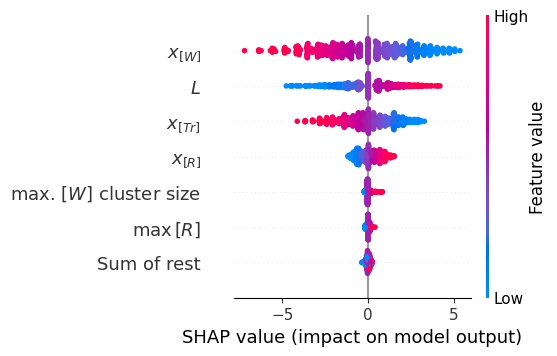

In [4]:
shap.plots.beeswarm(
    shap_values_gpr, plot_size=[5.5, 4 / 6 * 5.5], max_display=7, show=False
)

ax = plt.gca()

current_labels = ax.get_yticklabels()
new_labels = current_labels
print(new_labels[0])
new_labels[0] = "Sum of rest"

ax.set_yticklabels(new_labels)

plt.tight_layout()
plt.savefig("figures/BaseSHAP.jpg", dpi=600)
plt.show()

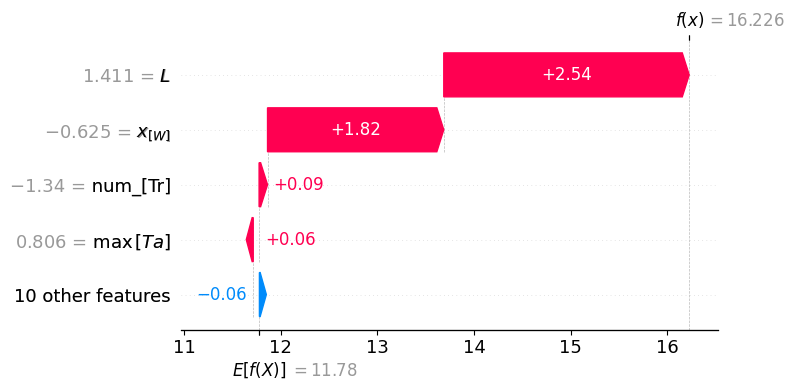

In [5]:
shap.plots.waterfall(shap_values_gpr[42], max_display=5, show=False)

plt.tight_layout()
# plt.savefig('figures/BaseSHAP_single.jpg',dpi=600)
plt.show()

# Hybrid model

In [6]:
new_base = shap_values_remain.base_values + shap_values_lin.base_values
new_data = np.concatenate([shap_values_lin.data, shap_values_remain.data], axis=1)
new_vals = np.concatenate([shap_values_lin.values, shap_values_remain.values], axis=1)
feature_names = [
    r"$[W]$, prior",
    r"$[Ta]$, prior",
    r"$[R]$, prior",
] + shap_values_remain.feature_names
print(feature_names)

shap_all = shap.Explanation(
    values=new_vals, base_values=new_base, data=new_data, feature_names=feature_names
)

['$[W]$, prior', '$[Ta]$, prior', '$[R]$, prior', 'num_[W]', 'max_[W]', 'num_[Tr]', 'max_[Tr]', 'num_[Ta]', 'max_[Ta]', 'num_[R]', 'max_[R]', '[W]', '[Tr]', '[Ta]', '[R]', 'rel_shannon', 'length']


In [7]:
print(shap_all.feature_names)
new_features = [
    "$[W]$, prior",
    "$[Ta]$, prior",
    "$[R]$, prior",
    r"num. $[W]$ clusters",
    r"max. $[W]$ cluster size",
    "num_[Tr]",
    "max_[Tr]",
    "num_[Ta]",
    "max_[Ta]",
    "num_[R]",
    "max_[R]",
    "$x_{[W]}$",
    "[Tr]",
    "[Ta]",
    "[R]",
    "rel_shannon",
    "length",
]
shap_all.feature_names = new_features
print(shap_all.feature_names)

['$[W]$, prior', '$[Ta]$, prior', '$[R]$, prior', 'num_[W]', 'max_[W]', 'num_[Tr]', 'max_[Tr]', 'num_[Ta]', 'max_[Ta]', 'num_[R]', 'max_[R]', '[W]', '[Tr]', '[Ta]', '[R]', 'rel_shannon', 'length']
['$[W]$, prior', '$[Ta]$, prior', '$[R]$, prior', 'num. $[W]$ clusters', 'max. $[W]$ cluster size', 'num_[Tr]', 'max_[Tr]', 'num_[Ta]', 'max_[Ta]', 'num_[R]', 'max_[R]', '$x_{[W]}$', '[Tr]', '[Ta]', '[R]', 'rel_shannon', 'length']


Text(0, 0, 'Sum of 11 other features')


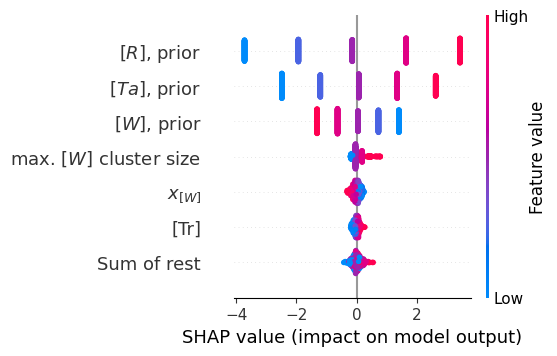

In [8]:
shap.plots.beeswarm(shap_all, plot_size=[5.5, 4 / 6 * 5.5], max_display=7, show=False)

ax = plt.gca()

current_labels = ax.get_yticklabels()
new_labels = current_labels
print(new_labels[0])
new_labels[0] = "Sum of rest"

ax.set_yticklabels(new_labels)

plt.tight_layout()
plt.savefig("figures/PriorSHAP.jpg", dpi=600)
plt.show()